# BigBasket Category Performance Diagnostic — Part 4: Pandas Cleaning & Cross-Validation

This notebook cleans the raw, messy `orders_raw.csv` export from scratch and checks that the findings agree with Part 1's SQL diagnostic.

## Task 1 — Load and inspect

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

orders = pd.read_csv("orders_raw.csv")
products = pd.read_csv("products.csv")

print(orders.info())
print(orders.describe())
print(orders['status'].value_counts())


<class 'pandas.DataFrame'>
RangeIndex: 508 entries, 0 to 507
Data columns (total 11 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   order_id       508 non-null    int64  
 1   order_date     508 non-null    str    
 2   customer_name  508 non-null    str    
 3   city           508 non-null    str    
 4   category       508 non-null    str    
 5   product_id     508 non-null    int64  
 6   quantity       508 non-null    int64  
 7   amount_inr     498 non-null    float64
 8   payment_mode   508 non-null    str    
 9   status         508 non-null    str    
 10  rating         439 non-null    float64
dtypes: float64(2), int64(3), str(6)
memory usage: 43.8 KB
None
         order_id  product_id    quantity   amount_inr      rating
count  508.000000  508.000000  508.000000   498.000000  439.000000
mean   250.204724   15.476378    3.045276   257.530120    3.082005
std    144.594139    8.747467    1.364497   559.424136    1.364126
mi

**What looks wrong:**
- `orders_raw.csv` has more than 500 rows (duplicates were injected).
- `city` and `category` have mixed casing and stray whitespace (e.g. `"BENGALURU"`, `" mumbai "`, `"personal care"`).
- `amount_inr` has missing values (blank cells read in as `NaN`).
- Some `amount_inr` values are suspiciously large (40x the normal amount) — likely outliers.

## Task 2 — Remove duplicates

In [2]:
before = len(orders)
orders = orders.drop_duplicates(subset='order_id', keep='first').reset_index(drop=True)
after = len(orders)
print(f"Rows before: {before}, rows after: {after}, removed: {before - after}")
assert after == 500, "Expected exactly 500 rows after de-duplication"


Rows before: 508, rows after: 500, removed: 8


## Task 3 — Fix casing and whitespace

In [3]:
orders['city'] = orders['city'].str.strip().str.title()
orders['category'] = orders['category'].str.strip().str.title()

print("Distinct cities:", sorted(orders['city'].unique()))
print("Distinct categories:", sorted(orders['category'].unique()))
assert orders['city'].nunique() == 4
assert orders['category'].nunique() == 6


Distinct cities: ['Bengaluru', 'Hyderabad', 'Mumbai', 'Pune']
Distinct categories: ['Bakery', 'Dairy & Eggs', 'Fruits & Vegetables', 'Household Essentials', 'Personal Care', 'Snacks & Beverages']


## Task 4 — Handle missing values with stated business logic

`amount_inr` missing values are **excluded** from every revenue calculation below (a missing revenue figure is unknown, not zero — filling with 0 or a mean would silently distort totals).

`rating` is legitimately null for every `Cancelled`/`Pending` order (only `Delivered` orders get rated) — these nulls are left as-is; they are not a data-quality problem, just expected structure.

In [4]:
missing_amount = orders['amount_inr'].isna().sum()
print(f"Missing amount_inr rows: {missing_amount}")

# Rating nulls check — should equal Cancelled + Pending count
non_delivered_count = (orders['status'] != 'Delivered').sum()
rating_null_count = orders['rating'].isna().sum()
print(f"Non-Delivered orders: {non_delivered_count}, rating nulls: {rating_null_count}")

# Build the working frame used for all revenue calculations: exclude missing amount_inr
orders_valid = orders.dropna(subset=['amount_inr']).copy()
print(f"Rows retained for revenue calcs: {len(orders_valid)}")


Missing amount_inr rows: 10
Non-Delivered orders: 66, rating nulls: 66
Rows retained for revenue calcs: 490


## Task 5 — Detect and cap outliers with IQR (on Delivered, non-null amount_inr)

In [5]:
delivered = orders_valid[orders_valid['status'] == 'Delivered']

Q1 = delivered['amount_inr'].quantile(0.25)
Q3 = delivered['amount_inr'].quantile(0.75)
IQR = Q3 - Q1
upper_fence = Q3 + 1.5 * IQR
lower_fence = Q1 - 1.5 * IQR

print(f"Q1={Q1}, Q3={Q3}, IQR={IQR}, upper_fence={upper_fence}, lower_fence={lower_fence}")

outlier_mask = orders_valid['amount_inr'] > upper_fence
n_capped = outlier_mask.sum()
print(f"Rows capped: {n_capped}")

orders_valid['amount_inr'] = orders_valid['amount_inr'].clip(upper=upper_fence)


Q1=90.0, Q3=275.0, IQR=185.0, upper_fence=552.5, lower_fence=-187.5
Rows capped: 21


## Task 6 — Parse dates and create derived columns

In [6]:
orders_valid['order_date'] = pd.to_datetime(orders_valid['order_date'])
orders_valid['month'] = orders_valid['order_date'].dt.month
orders_valid['month_name'] = orders_valid['order_date'].dt.month_name()
orders_valid['revenue_per_unit'] = orders_valid['amount_inr'] / orders_valid['quantity']
orders_valid['is_delivered'] = orders_valid['status'] == 'Delivered'

orders_valid.head()


,order_id,order_date,customer_name,city,category,product_id,quantity,amount_inr,payment_mode,status,rating,month,month_name,revenue_per_unit,is_delivered
0,1,2026-03-09,Dev,Pune,Snacks & Beverages,13,5,175.0,UPI,Delivered,5.0,3,March,35.0,True
1,2,2026-05-22,Ayaan,Bengaluru,Snacks & Beverages,15,1,60.0,Debit Card,Delivered,5.0,5,May,60.0,True
2,3,2026-06-30,Yash,Bengaluru,Household Essentials,25,2,150.0,UPI,Delivered,2.0,6,June,75.0,True
3,4,2026-03-01,Sneha,Hyderabad,Snacks & Beverages,11,1,30.0,UPI,Delivered,4.0,3,March,30.0,True
4,5,2026-04-05,Rohit,Mumbai,Snacks & Beverages,14,2,220.0,Debit Card,Delivered,3.0,4,April,110.0,True


## Task 7 — Group, merge, and answer two business questions

In [7]:
# 7a. Top category by revenue (Delivered only)
delivered_clean = orders_valid[orders_valid['is_delivered']]
category_revenue = delivered_clean.groupby('category')['amount_inr'].sum().sort_values(ascending=False)
print(category_revenue)
top_category = category_revenue.idxmax()
print(f"\nTop category by revenue: {top_category}")


category
Household Essentials    20910.0
Bakery                  14975.0
Personal Care           14594.5
Dairy & Eggs            13675.0
Snacks & Beverages      11312.5
Fruits & Vegetables      9170.0
Name: amount_inr, dtype: float64

Top category by revenue: Household Essentials


In [8]:
# 7b. Merge with products.csv to bring in supplier, then find top supplier
merged = delivered_clean.merge(products[['product_id', 'supplier']], on='product_id', how='left')
supplier_revenue = merged.groupby('supplier')['amount_inr'].sum().sort_values(ascending=False)
print(supplier_revenue)
top_supplier = supplier_revenue.idxmax()
print(f"\nTop supplier by revenue: {top_supplier}")


supplier
HomeEssentials Traders    20910.0
BakeHouse Supplies        18550.0
CarePlus Distributors     14594.5
DairyBest Ltd             10710.0
SnackHub India             7737.5
FreshFarms Co              5490.0
GreenValley Traders        3680.0
CountryEggs Farms          2965.0
Name: amount_inr, dtype: float64

Top supplier by revenue: HomeEssentials Traders


In [9]:
# 7c. Cross-validate against Part 1's SQL diagnostic
expected_category = "Household Essentials"
expected_supplier = "HomeEssentials Traders"

print(f"My top category: {top_category} | Part 1 SQL top category: {expected_category} | Match: {top_category == expected_category}")
print(f"My top supplier: {top_supplier} | Part 1 SQL top supplier: {expected_supplier} | Match: {top_supplier == expected_supplier}")


My top category: Household Essentials | Part 1 SQL top category: Household Essentials | Match: True
My top supplier: HomeEssentials Traders | Part 1 SQL top supplier: HomeEssentials Traders | Match: True


## Task 8 — Visualize

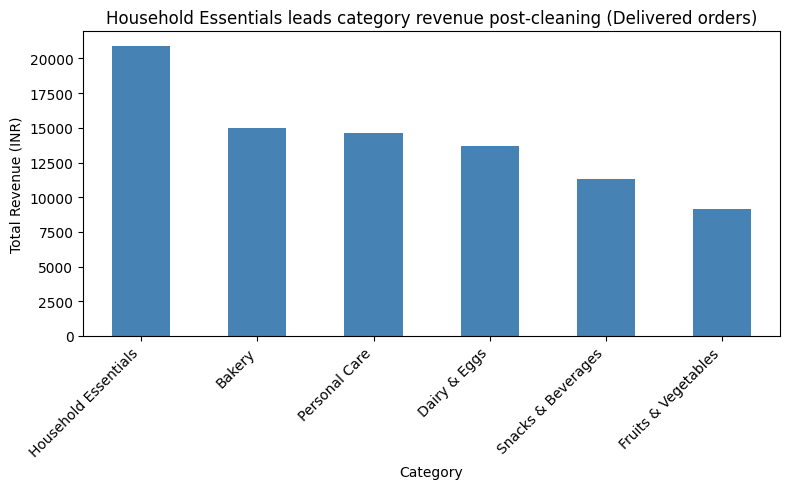

In [10]:
fig, ax = plt.subplots(figsize=(8,5))
category_revenue.plot(kind='bar', ax=ax, color='steelblue')
ax.set_title(f"{top_category} leads category revenue post-cleaning (Delivered orders)")
ax.set_xlabel("Category")
ax.set_ylabel("Total Revenue (INR)")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


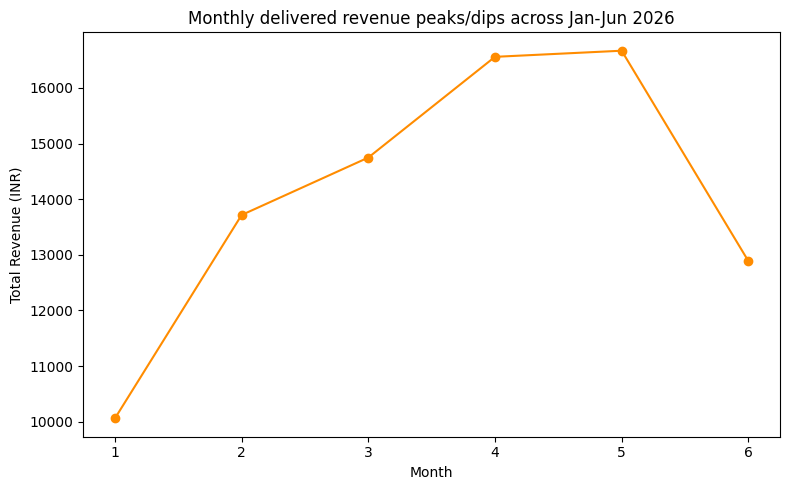

In [11]:
monthly_trend = delivered_clean.groupby('month')['amount_inr'].sum()
fig, ax = plt.subplots(figsize=(8,5))
monthly_trend.plot(kind='line', marker='o', ax=ax, color='darkorange')
ax.set_title("Monthly delivered revenue peaks/dips across Jan-Jun 2026")
ax.set_xlabel("Month")
ax.set_ylabel("Total Revenue (INR)")
plt.tight_layout()
plt.show()


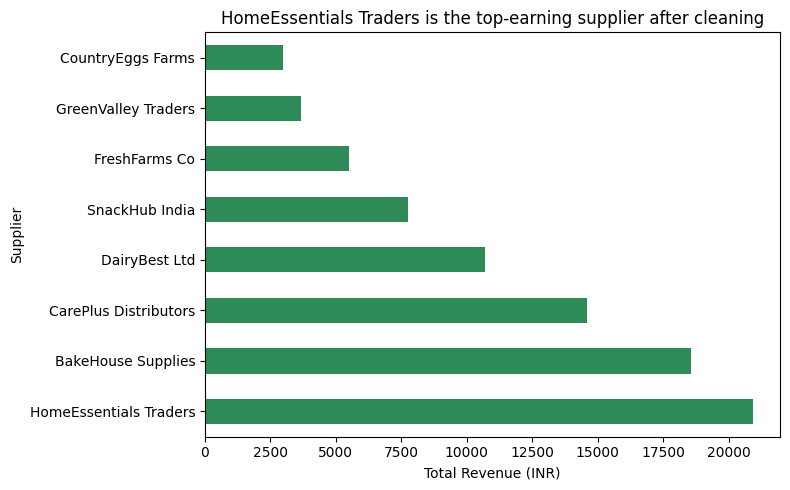

In [12]:
fig, ax = plt.subplots(figsize=(8,5))
supplier_revenue.plot(kind='barh', ax=ax, color='seagreen')
ax.set_title(f"{top_supplier} is the top-earning supplier after cleaning")
ax.set_xlabel("Total Revenue (INR)")
ax.set_ylabel("Supplier")
plt.tight_layout()
plt.show()


## Task 9 — Insights

**Observation 1**
- What: [Fill in with your actual numbers, e.g. "Household Essentials generated ₹X in delivered revenue post-cleaning, the highest of all 6 categories."]
- Why it matters: [e.g. "Confirms the category is BigBasket's strongest revenue driver and validates Part 1's SQL finding independently."]
- Next step: [e.g. "Investigate whether this is driven by order volume or high-ticket items, to decide if marketing spend should follow."]

**Observation 2**
- What: [Fill in, e.g. number of rows capped by the IQR fence and their effect on category totals.]
- Why it matters: [e.g. explains why a handful of large but real orders shouldn't be mistaken for data errors.]
- Next step: [e.g. "Set up an alert for orders above the IQR fence going forward, rather than only catching them at analysis time."]

**Observation 3**
- What: [Fill in, e.g. the supplier concentration finding.]
- Why it matters: [e.g. dependency risk if one supplier accounts for a large share of a category's revenue.]
- Next step: [e.g. "Category team should evaluate diversifying suppliers for the top category."]


## Task 10 — AI-assisted prompt #2

See `ai_log.md` for the RCTCF-structured prompt used to help debug the IQR outlier-capping logic above, along with the verification step performed.